In [1]:
import sys
sys.path.append('../')

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from helpers.cm26 import DatasetCM26, read_datasets
from helpers.selectors import *
from helpers.operators import Coarsen, Filtering, Subsampling, CoarsenKochkov, CoarsenWeighted, CoarsenKochkovMinMax
from helpers.state_functions import *
from helpers.plot_helpers import *

#import hvplot.xarray
import hvplot
import cmocean

%load_ext autoreload
%autoreload 3

# Plotting functions

In [2]:
def read_skill(exp='subfilter/FGR3/EXP1', factors=[4,9,12,15], base_path='/scratch/pp2681/mom6/CM26_ML_models/ocean3d/'):
    ds = {}
    for factor in factors:
        data = xr.open_dataset(f'{base_path}/{exp}/skill-test/factor-{factor}.nc', chunks={'zl':1})
        data['zl'] = -data['zl']

        try:
            # Compute RMSE and MSE metrics
            mask = xr.where(data.RMSE_map == 0., np.nan, 1.)
            
            data['MSE'] = (data.RMSE_map.astype('float64')**2 * mask).mean(['xh', 'yh']).compute()
            data['RMSE'] = np.sqrt(data['MSE'])
    
            data['MSET'] = (data.RMSET_map.astype('float64')**2 * mask).mean(['xh', 'yh']).compute()
            data['RMSET'] = np.sqrt(data['MSET'])
        except:
            pass
        
        ds[factor] = data
        
    return ds

In [3]:
import cmocean
import matplotlib.patches as patches
def plot_metric(exp=None, metric='R2_away',vmin=-1,vmax=1,cmap=cmocean.cm.balance,err_format="%.2f", show_numbers=True, title=False, xlabel=False, ylabel=False):
    data = xr.concat([exp[factor][metric] for factor in [4,9,12,15]], dim='factor')
    im = data.drop_vars(['zl']).plot(x='factor', y='zl',cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)

    if show_numbers:
    # Add text annotations
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                plt.text(i, j, err_format % float(data[i,j]),
                        ha='center', va='center', color='white', fontsize=10)

    rectangle = patches.Rectangle(
                                    (1 - 0.5, 0 - 0.5),  # Lower-left corner of the rectangle
                                    1,  # Width (1 cell)
                                    1,  # Height (1 cell)
                                    linewidth=2,  # Border thickness
                                    edgecolor='y',  # Border color
                                    facecolor='none',  # No fill color
                                )
    plt.gca().add_patch(rectangle)

    rectangle = patches.Rectangle(
                                    (0 - 0.5, 0 - 0.5),  # Lower-left corner of the rectangle
                                    1,  # Width (1 cell)
                                    1,  # Height (1 cell)
                                    linewidth=2,  # Border thickness
                                    edgecolor='tab:orange',  # Border color
                                    facecolor='none',  # No fill color
                                )
    plt.gca().add_patch(rectangle)
    
    
    if ylabel:
        plt.yticks(np.arange(10),[5, 55, 110, 180,330, 730,1500,2500,3500,4500]);
        plt.ylabel('Depth $z$ ($\mathrm{m}$)')
    else:
        plt.yticks(np.arange(10),['']*10);
        plt.ylabel('')
    
    if xlabel:
        plt.xticks(np.arange(4),['$0.4^\circ$','$0.9^\circ$','$1.2^\circ$','$1.5^\circ$']);
        plt.xlabel('Coarse-grid spacing, $\Delta$')
    else:
        plt.xticks(np.arange(4), ['']*4)
        plt.xlabel('')
        
    if metric == 'R2':
        title_str = '$R^2$'
    elif metric == 'corr':
        title_str = 'Correlation'
    elif metric == 'opt_scaling':
        title_str = 'Optimal scaling'
    
    mean_val = float(data.mean())
    min_val = float(data.min())
    max_val = float(data.max())
    
    if title:
        plt.title(metric+f' = ${err_format}$ $({err_format}-{err_format})$' % (mean_val,min_val,max_val), fontsize=12)
    else:
        plt.title('')
    
    plt.gca().invert_yaxis()
    return im

In [4]:
ds = read_datasets(['validate'], [4,9], subfilter='subfilter-large')

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-4
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-9


In [5]:
ann_exp1 = read_skill('subfilter/FGR3/EXP1'); # Our default ANN

In [6]:
data = {}
for key in ['default', 'factor-4-depth-5', 'factor-9-depth-5', 'no-scaling-factor-4-depth-0',  'no-scaling-factor-9-depth-0',
'factor-4-depth-0',  'factor-9-depth-0',  'no-scaling',        'no-scaling-factor-4-depth-5',  'no-scaling-factor-9-depth-5']:
    data[key] = read_skill(f'subfilter-large/FGR3/dimensional-scaling/20/{key}');

In [7]:
data['ZB20-factor-9-depth-0'] = read_skill(f'subfilter-large/FGR3/ZB20/factor-9-depth-0');

In [8]:
data['ZB20-all'] = read_skill(f'subfilter-large/FGR3/ZB20/fit-all-data');

In [9]:
SGS_KE = lambda x: -0.5 * (x.Txx_pred + x.Tyy_pred)
SGS_KE_target = lambda x: -0.5 * (x.Txx + x.Tyy)

In [10]:
import cartopy.crs as ccrs
from matplotlib.colors import LinearSegmentedColormap

# Get the 'balance' colormap from cmocean
original_cmap = cmocean.cm.balance
#original_cmap = plt.cm.PuOr_r

# Extract the red part (positive values, typically > 0.5 in normalized space)
n_colors = 256  # Number of colors in the colormap
colors = original_cmap(np.linspace(0.5, 1, n_colors // 2))  # Keep the red part

# Create a new colormap with only the red part
red_cmap = LinearSegmentedColormap.from_list("RedBalance", colors)

def plot_SGS_KE(array_3d, param, zl=0, central_latitude=5, central_longitude=-70, ax=None, cmap=red_cmap, vmin=0., vmax=0.05, text=None):
    mask_nan = xr.where(param.wet == 1., 1., np.nan).drop_vars('zl')

    array = (mask_nan * array_3d).isel(zl=zl).compute()
    if ax is None:
        ax = plt.subplot(1,1,1,projection = ccrs.Orthographic(central_latitude=central_latitude, central_longitude=central_longitude))
    
    ax.coastlines(rasterized=True);
    cmap.set_bad('gray')

    im = ax.pcolormesh(param.geolon_u, param.geolat_u, array, cmap=cmap, vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree(), rasterized=True)

    if text is not None:
        ax.text(-71,-17, text, transform=ccrs.Geodetic(), color='white', fontsize=9)
    return im

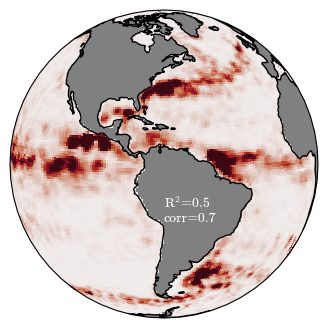

In [344]:
im = plot_SGS_KE(SGS_KE(data['factor-9-depth-0'][9]), ds['validate-9'].param, text='R$^2$=0.5\ncorr=0.7')
#plt.colorbar(im)

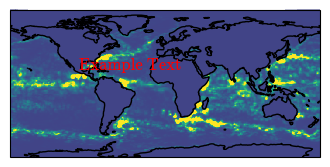

In [318]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

x = SGS_KE(data['factor-9-depth-0'][9]).isel(zl=0)
param = ds['validate-9'].param

# Create a map with Cartopy
#fig, ax = plt.subplots(subplot_kw={"projection": ccrs.Orthographic(central_latitude=5, central_longitude=-70)})
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
ax.coastlines()

# Add text to the plot
ax.pcolormesh(param.geolon_u, param.geolat_u, x, vmax=0.05, transform = ccrs.PlateCarree())
ax.text(-100, 20, "Example Text", color="red", fontsize=12, transform=ccrs.Geodetic())

# Show the plot
plt.show()


Text(0.5, 1.0, 'ZB20')

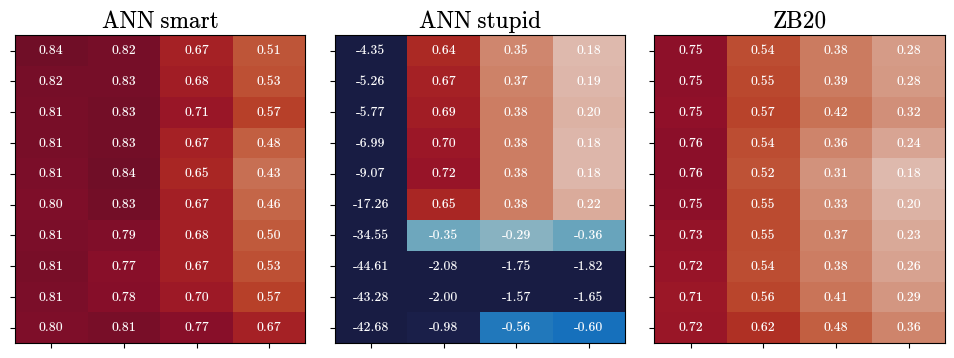

In [362]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plot_metric(data['factor-9-depth-0'], 'R2T_away', vmin=-1)
plt.title('ANN smart')

plt.subplot(1,3,2)
plot_metric(data['no-scaling-factor-9-depth-0'], 'R2T_away', vmin=-1)
plt.title('ANN stupid')

plt.subplot(1,3,3)
plot_metric(data['ZB20-factor-9-depth-0'], 'R2T_away', vmin=-1)
plt.title('ZB20')

Text(0.5, 1.0, 'ZB20')

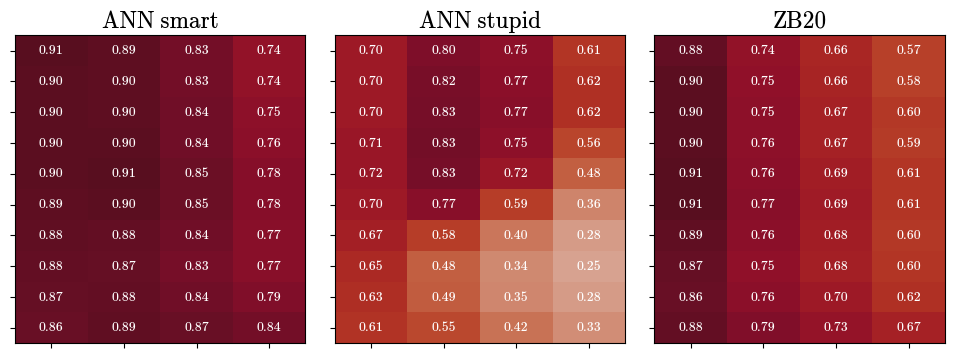

In [363]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plot_metric(data['factor-9-depth-0'], 'corr_T_away', vmin=-1)
plt.title('ANN smart')

plt.subplot(1,3,2)
plot_metric(data['no-scaling-factor-9-depth-0'], 'corr_T_away', vmin=-1)
plt.title('ANN stupid')

plt.subplot(1,3,3)
plot_metric(data['ZB20-factor-9-depth-0'], 'corr_T_away', vmin=-1)
plt.title('ZB20')

# Combined figure

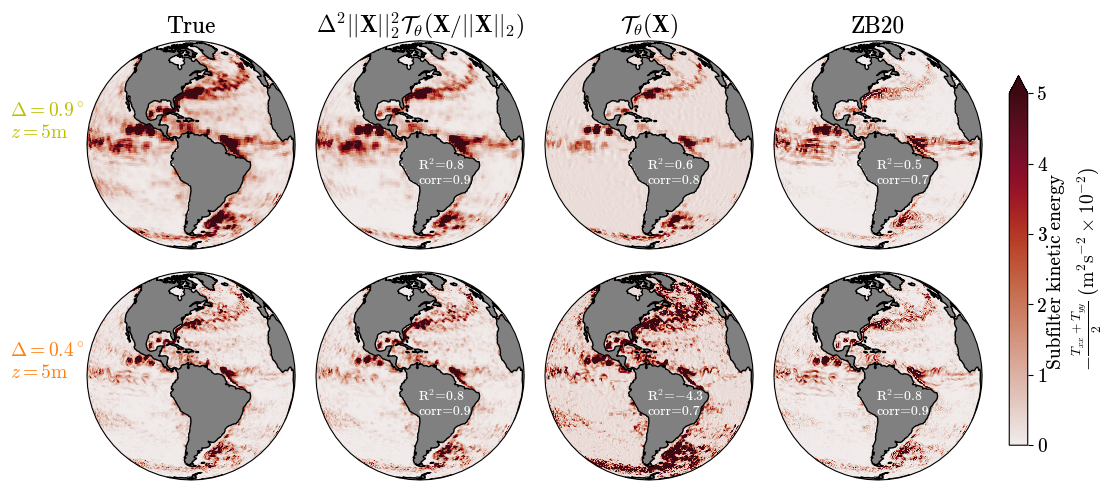

In [412]:
default_rcParams({'figure.subplot.wspace': 0.1, 'figure.subplot.hspace': 0.0, 'font.size':14})
fig = plt.figure(figsize=(14,6))

# factor=9, depth=5
ax = plt.subplot(2,4,1,projection = ccrs.Orthographic(central_latitude=5, central_longitude=-70))
plot_SGS_KE(SGS_KE_target(data['factor-9-depth-0'][9]), ds['validate-9'].param, zl=0, ax=ax)
plt.title('True')

ax = plt.subplot(2,4,2,projection = ccrs.Orthographic(central_latitude=5, central_longitude=-70))
plot_SGS_KE(SGS_KE(data['factor-9-depth-0'][9]), ds['validate-9'].param, zl=0, ax=ax, text='R$^2$=0.8\ncorr=0.9')
plt.title('$ \\Delta^2 ||\\mathbf{X}||_2^2 \\mathcal{T}_{\\theta} (\\mathbf{X} / ||\\mathbf{X}||_2) $')

ax = plt.subplot(2,4,3,projection = ccrs.Orthographic(central_latitude=5, central_longitude=-70))
plot_SGS_KE(SGS_KE(data['no-scaling-factor-9-depth-0'][9]), ds['validate-9'].param, zl=0, ax=ax, text='R$^2$=0.6\ncorr=0.8')
plt.title('$ \\mathcal{T}_{\\theta}(\\mathbf{X}) $')

ax = plt.subplot(2,4,4,projection = ccrs.Orthographic(central_latitude=5, central_longitude=-70))
plot_SGS_KE(SGS_KE(data['ZB20-factor-9-depth-0'][9]), ds['validate-9'].param, zl=0, ax=ax, text='R$^2$=0.5\ncorr=0.7')
#plt.title('ZB20\n$0.4\Delta^2 \\left(\\overline{\\sigma}_S^2 + \\overline{\\sigma}_T^2 + \\overline{\\omega}_S^2 \\right)$')
plt.title('ZB20')

# factor=4, depth=5
ax = plt.subplot(2,4,5,projection = ccrs.Orthographic(central_latitude=5, central_longitude=-70))
plot_SGS_KE(SGS_KE_target(data['factor-9-depth-0'][4]), ds['validate-4'].param, zl=0, ax=ax)

ax = plt.subplot(2,4,6,projection = ccrs.Orthographic(central_latitude=5, central_longitude=-70))
plot_SGS_KE(SGS_KE(data['factor-9-depth-0'][4]), ds['validate-4'].param, zl=0, ax=ax, text='R$^2$=0.8\ncorr=0.9')

ax = plt.subplot(2,4,7,projection = ccrs.Orthographic(central_latitude=5, central_longitude=-70))
plot_SGS_KE(SGS_KE(data['no-scaling-factor-9-depth-0'][4]), ds['validate-4'].param, zl=0, ax=ax, text='R$^2$=$-$4.3\ncorr=0.7')

ax = plt.subplot(2,4,8,projection = ccrs.Orthographic(central_latitude=5, central_longitude=-70))
im_SGS_KE = plot_SGS_KE(SGS_KE(data['ZB20-factor-9-depth-0'][4]), ds['validate-4'].param, zl=0, ax=ax, text='R$^2$=0.8\ncorr=0.9')

cbar = plt.colorbar(im_SGS_KE, ax=plt.gcf().axes, shrink=0.8, extend='max', pad=0.025, 
             label='Subfilter kinetic energy \n$-\\frac{T_{xx} + T_{yy}}{2}$ ($\mathrm{m}^2\mathrm{s}^{-2}\\times 10^{-2}$)')
cbar.set_ticks(np.arange(6) * 1e-2)
cbar.set_ticklabels(np.arange(6))

fig.text(0.07,0.7, '$\\Delta=0.9^\circ$\n$z=5\mathrm{m}$', color='y')
fig.text(0.07,0.3, '$\\Delta=0.4^\circ$\n$z=5\mathrm{m}$', color='tab:orange')

plt.savefig('figures/SGS-KE-snapshot.pdf', dpi=200)

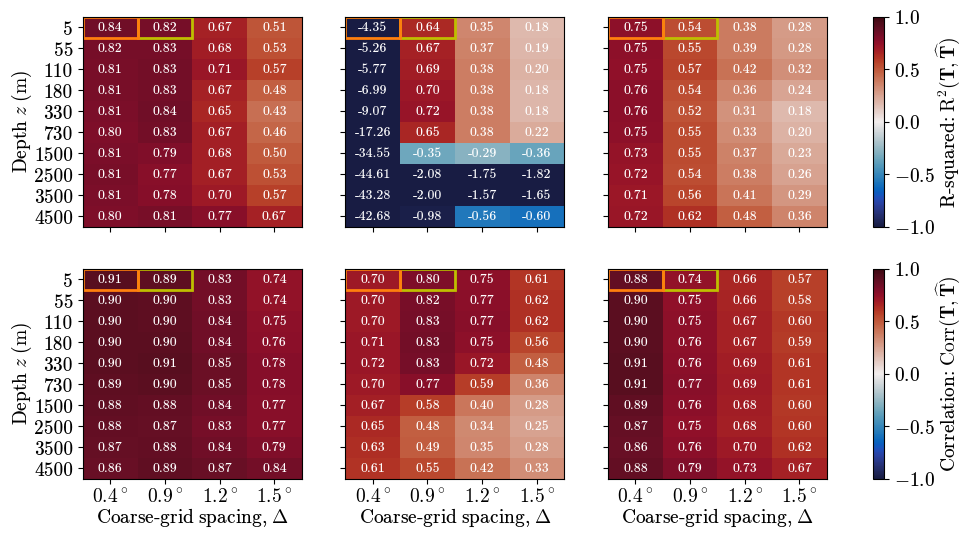

In [415]:
default_rcParams({'figure.subplot.wspace': 0.2, 'figure.subplot.hspace': 0.2, 'font.size':14})
fig = plt.figure(figsize=(12,6))

plt.subplot(2,3,1)
plot_metric(data['factor-9-depth-0'], 'R2T_away', ylabel=True);
plt.subplot(2,3,2)
plot_metric(data['no-scaling-factor-9-depth-0'], 'R2T_away');
plt.subplot(2,3,3)
im_R2 = plot_metric(data['ZB20-factor-9-depth-0'], 'R2T_away');

plt.subplot(2,3,4)
plot_metric(data['factor-9-depth-0'], 'corr_T_away', ylabel=True, xlabel=True);
plt.subplot(2,3,5)
plot_metric(data['no-scaling-factor-9-depth-0'], 'corr_T_away', xlabel=True);
plt.subplot(2,3,6)
im_corr = plot_metric(data['ZB20-factor-9-depth-0'], 'corr_T_away', xlabel=True);

axes = plt.gcf().axes
plt.colorbar(im_R2, ax=axes[0:3], label='R-squared: $\mathrm{R}^2(\\mathbf{T},\\widehat{\\mathbf{T}})$')
plt.colorbar(im_corr, ax=axes[3:], label='Correlation: $\\mathrm{Corr}(\\mathbf{T},\\widehat{\\mathbf{T}})$')

plt.savefig('figures/offline-metrics.pdf', dpi=200)

# No reference

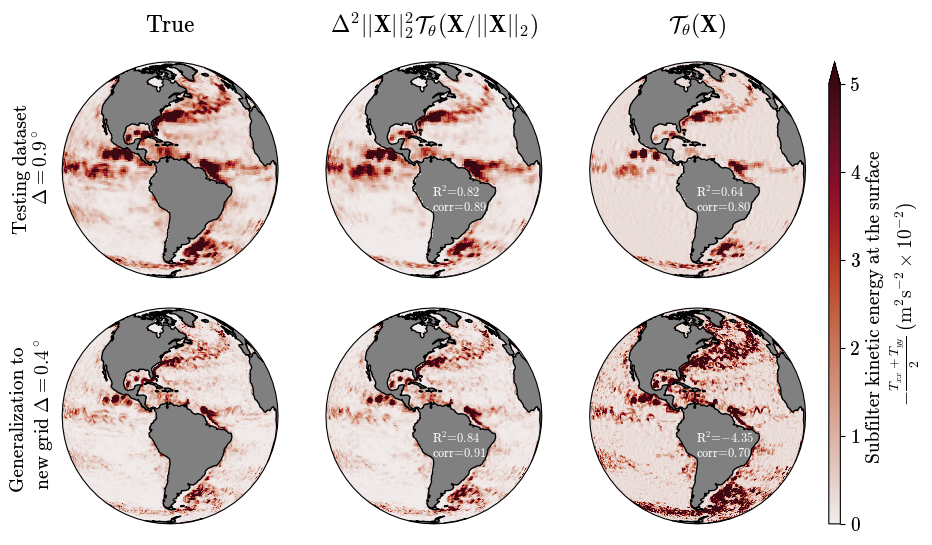

In [36]:
default_rcParams({'figure.subplot.wspace': 0.1, 'figure.subplot.hspace': 0.14, 'font.size':14})
fig = plt.figure(figsize=(12,6))

# factor=9, depth=5
ax = plt.subplot(2,3,1,projection = ccrs.Orthographic(central_latitude=5, central_longitude=-70))
plot_SGS_KE(SGS_KE_target(data['factor-9-depth-0'][9]), ds['validate-9'].param, zl=0, ax=ax)
plt.title('True', y=1.1)

ax = plt.subplot(2,3,2,projection = ccrs.Orthographic(central_latitude=5, central_longitude=-70))
plot_SGS_KE(SGS_KE(data['factor-9-depth-0'][9]), ds['validate-9'].param, zl=0, ax=ax, text='R$^2$=$0.82$\ncorr=$0.89$')
plt.title('$ \\Delta^2 ||\\mathbf{X}||_2^2 \\mathcal{T}_{\\theta} (\\mathbf{X} / ||\\mathbf{X}||_2) $', y=1.1)

ax = plt.subplot(2,3,3,projection = ccrs.Orthographic(central_latitude=5, central_longitude=-70))
plot_SGS_KE(SGS_KE(data['no-scaling-factor-9-depth-0'][9]), ds['validate-9'].param, zl=0, ax=ax, text='R$^2$=$0.64$\ncorr=$0.80$')
plt.title('$ \\mathcal{T}_{\\theta}(\\mathbf{X}) $', y=1.1)

# factor=4, depth=5
ax = plt.subplot(2,3,4,projection = ccrs.Orthographic(central_latitude=5, central_longitude=-70))
plot_SGS_KE(SGS_KE_target(data['factor-9-depth-0'][4]), ds['validate-4'].param, zl=0, ax=ax)

ax = plt.subplot(2,3,5,projection = ccrs.Orthographic(central_latitude=5, central_longitude=-70))
plot_SGS_KE(SGS_KE(data['factor-9-depth-0'][4]), ds['validate-4'].param, zl=0, ax=ax, text='R$^2$=$0.84$\ncorr=$0.91$')

ax = plt.subplot(2,3,6,projection = ccrs.Orthographic(central_latitude=5, central_longitude=-70))
im_SGS_KE = plot_SGS_KE(SGS_KE(data['no-scaling-factor-9-depth-0'][4]), ds['validate-4'].param, zl=0, ax=ax, text='R$^2$=$-4.35$\ncorr=$0.70$')

cbar = plt.colorbar(im_SGS_KE, ax=plt.gcf().axes, shrink=1, extend='max', pad=0.025, aspect=40, 
             label='Subfilter kinetic energy at the surface \n$-\\frac{T_{xx} + T_{yy}}{2}$ ($\mathrm{m}^2\mathrm{s}^{-2}\\times 10^{-2}$)')
cbar.set_ticks(np.arange(6) * 1e-2)
cbar.set_ticklabels(np.arange(6))

fig.text(0.12,0.6, 'Testing dataset\n $\\Delta=0.9^\circ$', color='k', rotation=90, ha='center')
fig.text(0.12,0.17, 'Generalization to \n new grid $\\Delta=0.4^\circ$', color='k', rotation=90, ha='center')

plt.savefig('figures/SGS-KE-snapshot-small.pdf', dpi=200)

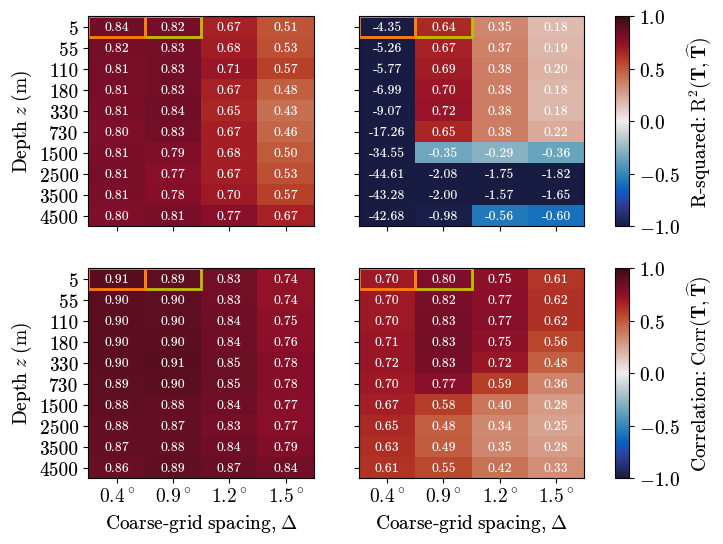

In [33]:
default_rcParams({'figure.subplot.wspace': 0.2, 'figure.subplot.hspace': 0.2, 'font.size':14})
fig = plt.figure(figsize=(8,6))

plt.subplot(2,2,1)
plot_metric(data['factor-9-depth-0'], 'R2T_away', ylabel=True);
plt.subplot(2,2,2)
im_R2 = plot_metric(data['no-scaling-factor-9-depth-0'], 'R2T_away');

plt.subplot(2,2,3)
plot_metric(data['factor-9-depth-0'], 'corr_T_away', ylabel=True, xlabel=True);
plt.subplot(2,2,4)
im_corr = plot_metric(data['no-scaling-factor-9-depth-0'], 'corr_T_away', xlabel=True);

axes = plt.gcf().axes
plt.colorbar(im_R2, ax=axes[0:2], label='R-squared: $\mathrm{R}^2(\\mathbf{T},\\widehat{\\mathbf{T}})$', aspect=15)
plt.colorbar(im_corr, ax=axes[2:], label='Correlation: $\\mathrm{Corr}(\\mathbf{T},\\widehat{\\mathbf{T}})$', aspect=15)

plt.savefig('figures/offline-metrics-small.pdf', dpi=200)

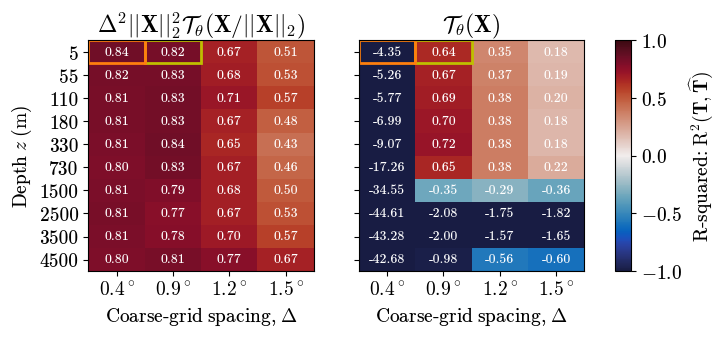

In [35]:
default_rcParams({'figure.subplot.wspace': 0.2, 'figure.subplot.hspace': 0.2, 'font.size':14})
fig = plt.figure(figsize=(8,3))

plt.subplot(1,2,1)
plot_metric(data['factor-9-depth-0'], 'R2T_away', ylabel=True, xlabel=True);
plt.title('$ \\Delta^2 ||\\mathbf{X}||_2^2 \\mathcal{T}_{\\theta} (\\mathbf{X} / ||\\mathbf{X}||_2) $')
plt.subplot(1,2,2)
im_R2 = plot_metric(data['no-scaling-factor-9-depth-0'], 'R2T_away', xlabel=True);
plt.title('$ \\mathcal{T}_{\\theta}(\\mathbf{X}) $')

axes = plt.gcf().axes
plt.colorbar(im_R2, ax=axes[0:2], label='R-squared: $\mathrm{R}^2(\\mathbf{T},\\widehat{\\mathbf{T}})$', aspect=15)

plt.savefig('figures/offline-metrics-small-small.pdf', dpi=200)

# Plot input/output features

In [4]:
#ds = DatasetCM26(source='3d-validate')
#ds2d = ds.select2d(time=0,zl=0)

In [270]:
ds = read_datasets(['validate'], [4], subfilter='subfilter-large')['validate-4']

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-4


In [271]:
ds2d = ds.select2d(time=0,zl=0)

In [272]:
def select_plot(array, time=None):
    return select_LatLon(array, Lat=(25, 35), Lon=(-85,-75), time=time)

In [273]:
sh_xy = select_plot(ds2d.nanvar(ds2d.data.sh_xy_h)).compute()

In [274]:
sh_xx = select_plot(ds2d.nanvar(ds2d.data.sh_xx)).compute()

In [275]:
vort_xy = select_plot(ds2d.nanvar(ds2d.data.rel_vort_h)).compute()

In [276]:
Txx = select_plot(ds2d.nanvar(ds2d.data.Txx)).compute()

In [277]:
Txy = select_plot(ds2d.nanvar(ds2d.data.Txy)).compute()

In [278]:
Tyy = select_plot(ds2d.nanvar(ds2d.data.Tyy)).compute()

In [279]:
import cartopy.crs as ccrs

def plot_strain(array, zl=0, cmap=cmocean.cm.balance, vmin=-2e-5, vmax=2e-5):
    
    ax = plt.subplot(1,1,1,projection = ccrs.PlateCarree())
    ax.coastlines(rasterized=True);
    cmap.set_bad('gray')

    array.plot.pcolormesh(cmap=cmap, vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree(), rasterized=True, add_colorbar=False)
    plt.title('')
    plt.gca().set_aspect(1)

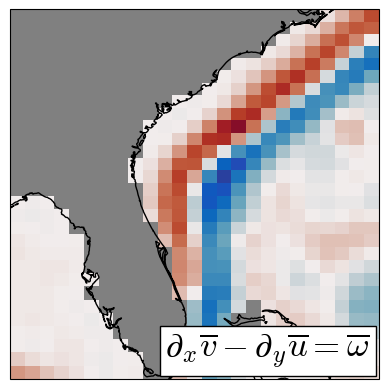

In [303]:
default_rcParams({})
plot_strain(vort_xy)
t = plt.gcf().text(0.467,0.155,'$\partial_x \overline{v} - \partial_y \overline{u}=\\overline{\omega}$', fontsize=25, color='black')
t.set_bbox(dict(facecolor='white', edgecolor='black'))
plt.savefig('figures/vort_xy.pdf', dpi=100)

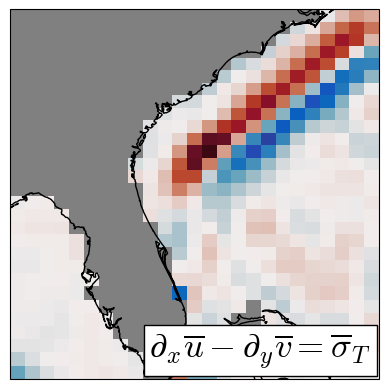

In [304]:
plot_strain(sh_xx)
t = plt.gcf().text(0.442,0.155,'$\partial_x \overline{u} - \partial_y \overline{v}=\\overline{\sigma}_{T}$', fontsize=25, color='black')
t.set_bbox(dict(facecolor='white', edgecolor='black'))
plt.savefig('figures/sh_xx.pdf', dpi=100)

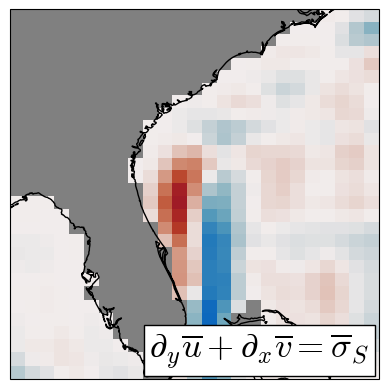

In [305]:
plot_strain(sh_xy)
t = plt.gcf().text(0.442,0.155,'$\partial_y \overline{u} + \partial_x \overline{v}=\\overline{\sigma}_{S}$', fontsize=25, color='black')
t.set_bbox(dict(facecolor='white', edgecolor='black'))
plt.savefig('figures/sh_xy.pdf', dpi=100)

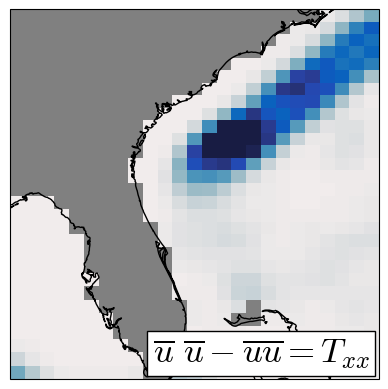

In [344]:
plot_strain(Txx, vmin=-0.25,vmax=0.25)
t = plt.gcf().text(0.447,0.145,'$\\overline{u} \, \, \\overline{u} - \\overline{uu}=T_{xx}$', fontsize=25, color='black')
t.set_bbox(dict(facecolor='white', edgecolor='black'))
plt.savefig('figures/Txx.pdf', dpi=100)

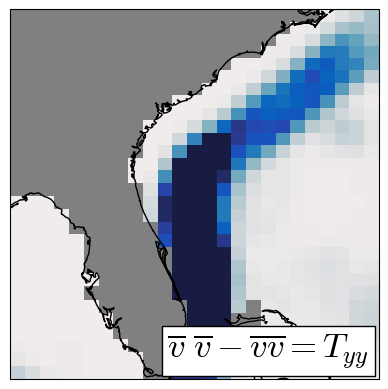

In [331]:
plot_strain(Tyy, vmin=-0.25,vmax=0.25)
t = plt.gcf().text(0.47,0.155,'$\\overline{v} \, \, \\overline{v} - \\overline{vv}=T_{yy}$', fontsize=25, color='black')
t.set_bbox(dict(facecolor='white', edgecolor='black'))
plt.savefig('figures/Tyy.pdf', dpi=100)

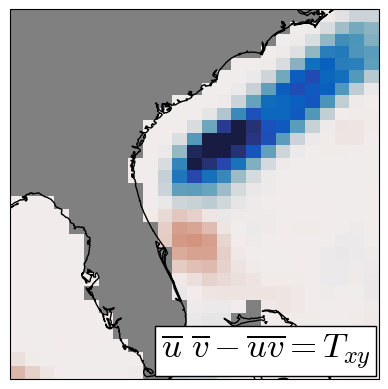

In [334]:
plot_strain(Txy, vmin=-0.25,vmax=0.25)
t = plt.gcf().text(0.46,0.155,'$\\overline{u} \, \, \\overline{v} - \\overline{uv}=T_{xy}$', fontsize=25, color='black')
t.set_bbox(dict(facecolor='white', edgecolor='black'))
plt.savefig('figures/Txy.pdf', dpi=100)

# Spectra

In [4]:
ann_exp1 = read_skill('subfilter/FGR3/EXP1'); # Our default ANN
ann_rossby = read_skill('subfilter/FGR3/EXP1');

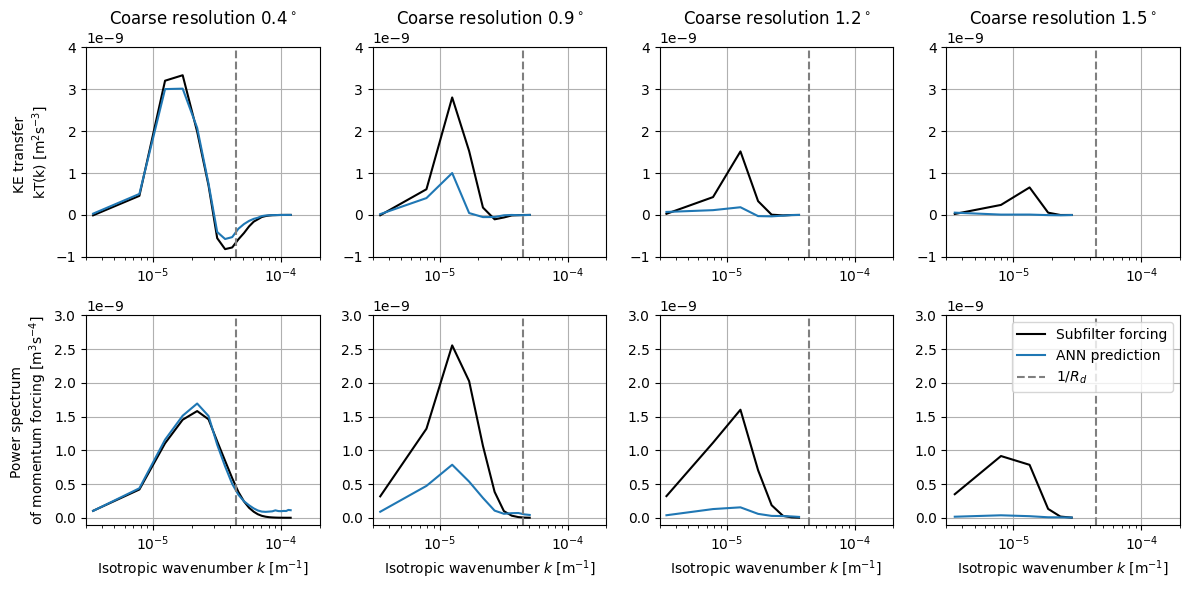

In [51]:
plt.figure(figsize=(12,6))

for column, factor, resolution in zip([0,1,2,3],[4,9,12,15],['$0.4^\circ$', '$0.9^\circ$', '$1.2^\circ$', '$1.5^\circ$']):
    plt.subplot(2,4,column+1)
    ann_exp1[factor].transfer_NA.mean('time').isel(zl=0).plot(color='k', label='Subfilter forcing')
    ann_exp1[factor].transfer_ZB_NA.mean('time').isel(zl=0).plot(label='ANN prediction')
    #plt.legend()
    plt.xscale('log')
    plt.title(f'Coarse resolution {resolution}')
    plt.tight_layout()
    plt.xlabel('')
    if column==0:
        plt.ylabel('KE transfer \nkT(k) [m$^2$s$^{-3}$]')
    else:
        plt.ylabel('')
    plt.xlim([3e-6, 2e-4])
    plt.ylim([-1e-9, 4e-9])
    plt.grid()
    plt.axvline(x=1/(22.6e+3), color='tab:gray', ls='--')

    plt.subplot(2,4,column+5)
    ann_exp1[factor].power_NA.mean('time').isel(zl=0).plot(color='k', label='Subfilter forcing')
    ann_exp1[factor].power_ZB_NA.mean('time').isel(zl=0).plot(label='ANN prediction')
    #plt.legend()
    plt.xscale('log')
    plt.title('')
    plt.tight_layout()
    plt.xlabel('Isotropic wavenumber $k$ [$\mathrm{m}^{-1}$]')
    if column==0:
        plt.ylabel('Power spectrum \nof momentum forcing [m$^3$s$^{-4}$]')
    else:
        plt.ylabel('')
    plt.xlim([3e-6, 2e-4])
    plt.ylim([-0.1e-9, 3e-9])
    plt.grid()
    plt.axvline(x=1/(22.6e+3), color='tab:gray', ls='--')

plt.plot(np.nan, np.nan, color='tab:gray', ls='--', label='$1/R_d$')
plt.legend()
plt.savefig('power-transfer.pdf')

In [5]:
# Why R2 is 0.5 but spectral properties are not accurate

In [43]:
from helpers.cm26 import read_datasets
ds = read_datasets(['validate'], subfilter='subfilter-large', FGR=3)

Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-4
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-9
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-12
Reading from folder /vast/pp2681/CM26_datasets/ocean3d/subfilter-large/FGR3/factor-15


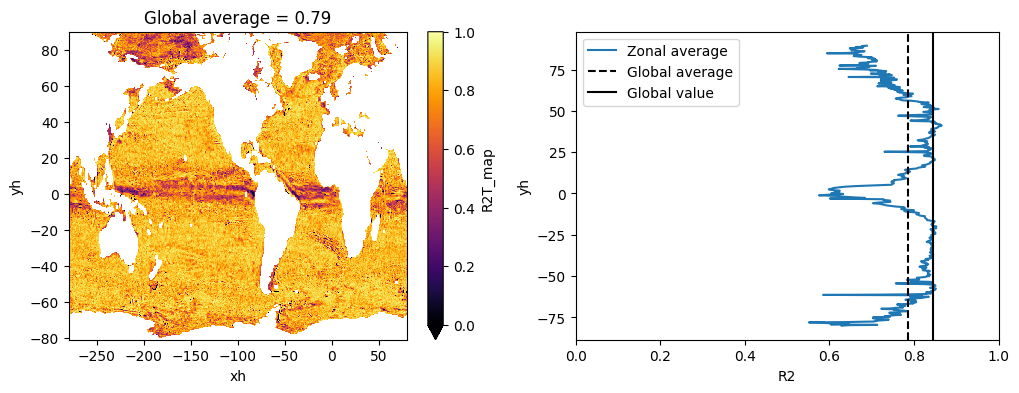

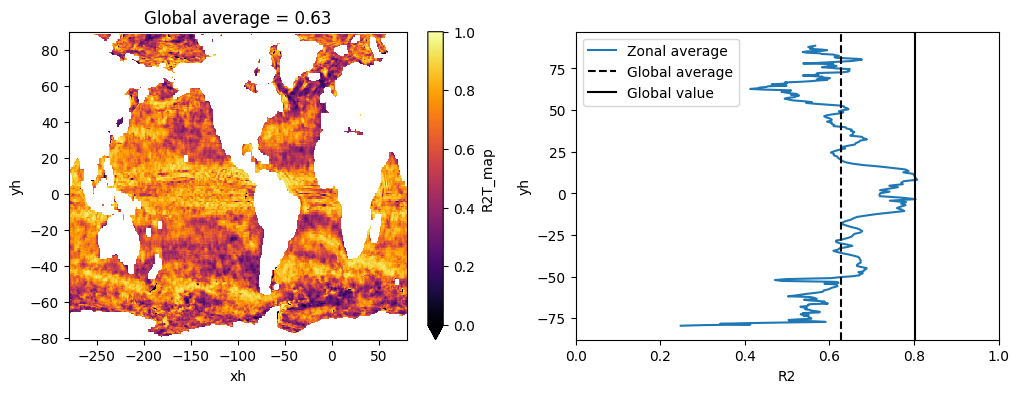

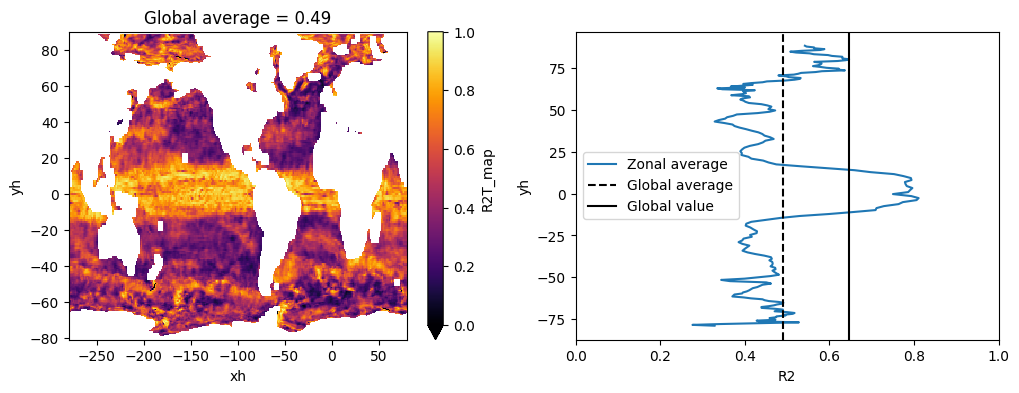

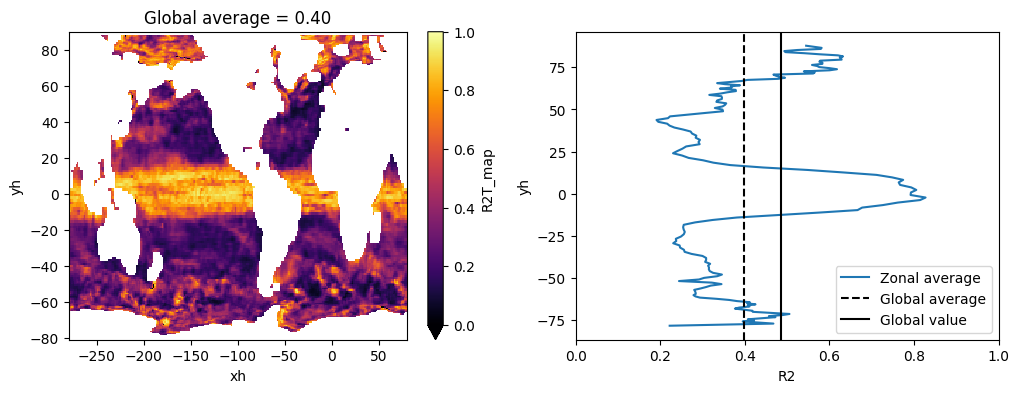

In [118]:
for factor in [4,9,12,15]:
    mask = ds[f'validate-{factor}'].param.wet
    grid = ds[f'validate-{factor}'].grid
    mask2 = propagate_mask(mask, grid, niter=2)
    mask2_nan = xr.where(mask2<0.5,np.nan,1.)
    
    plt.figure(figsize=(12,4))
    R2T_map = (mask2_nan.values * ann_exp1[factor].R2T_map).isel(zl=0)
    plt.subplot(1,2,1)
    R2T_map.plot(vmin=0, vmax=1, cmap='inferno')
    plt.title('Global average = %.2f' % R2T_map.mean())
    plt.subplot(1,2,2)
    R2T_map.mean('xh').plot(y='yh', label='Zonal average')
    plt.xlabel('R2')
    plt.axvline(x=R2T_map.mean(), color='k', ls='--', label='Global average')
    plt.axvline(x=ann_exp1[factor].R2T_away[0], color='k', label='Global value')
    plt.xlim([0,1])
    plt.legend()
    plt.title('')

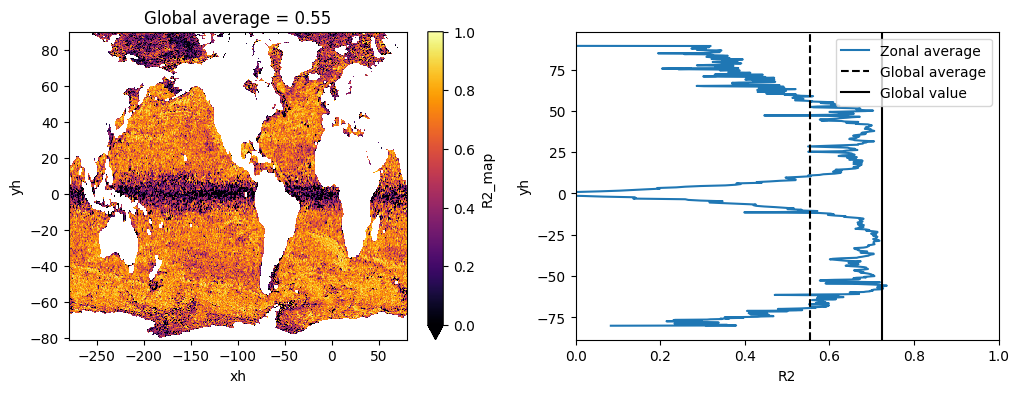

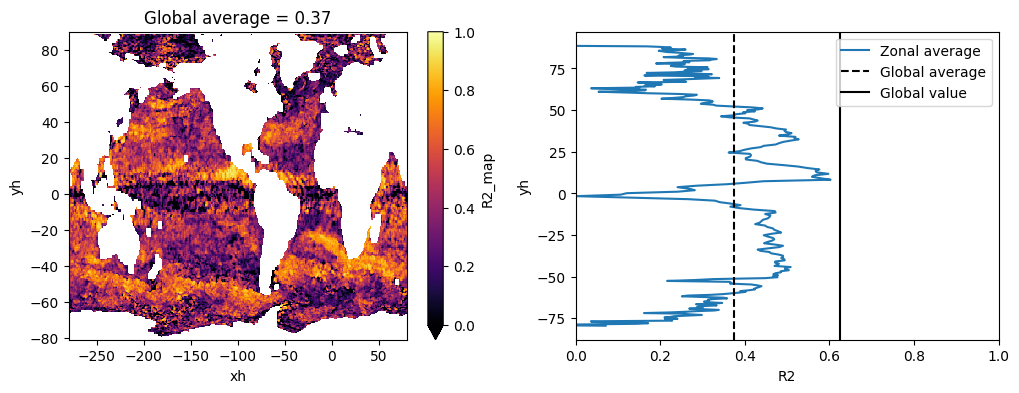

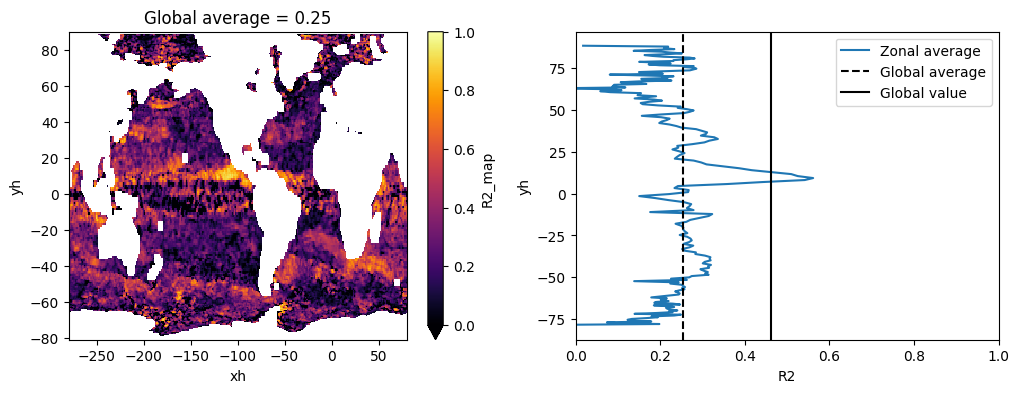

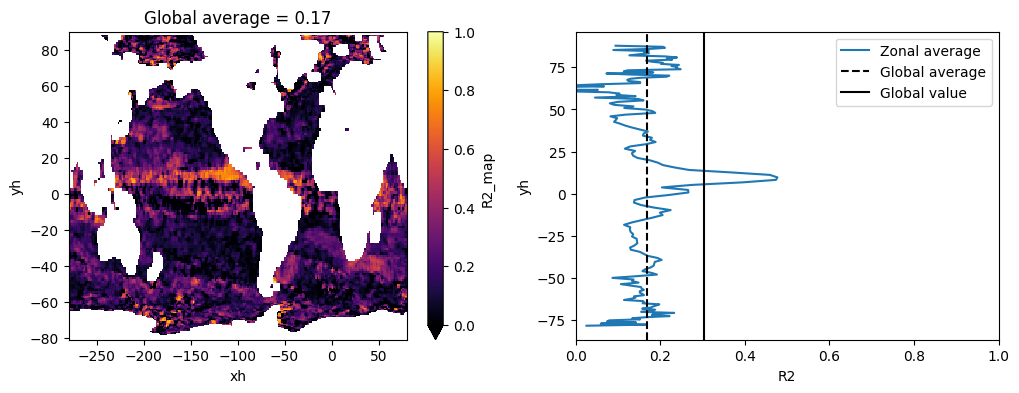

In [119]:
for factor in [4,9,12,15]:
    mask = ds[f'validate-{factor}'].param.wet
    grid = ds[f'validate-{factor}'].grid
    mask2 = propagate_mask(mask, grid, niter=2)
    mask2_nan = xr.where(mask2<0.5,np.nan,1.)
    
    plt.figure(figsize=(12,4))
    R2_map = (mask2_nan.values * ann_exp1[factor].R2_map).isel(zl=0)
    plt.subplot(1,2,1)
    R2_map.plot(vmin=0, vmax=1, cmap='inferno')
    plt.title('Global average = %.2f' % R2_map.mean())
    plt.subplot(1,2,2)
    R2_map.mean('xh').plot(y='yh', label='Zonal average')
    plt.xlabel('R2')
    plt.axvline(x=R2_map.mean(), color='k', ls='--', label='Global average')
    plt.axvline(x=ann_exp1[factor].R2_away[0], color='k', label='Global value')
    plt.xlim([0,1])
    plt.legend()
    plt.title('')

Correlation: 0.7835718519605774
Relative Error: 0.6715765514194019
R2 =  0.5620693914071246
R2 max =  0.6600562626072766
Optinal scaling: 1.6267968143790035
Nans [test/control]: [22194, 22194]


array([[<Axes: title={'center': 'Tested field'}, xlabel='xh', ylabel='yh'>,
        <Axes: title={'center': 'Control field'}, xlabel='xh', ylabel='yh'>],
       [<Axes: title={'center': 'Tested field $-$ Control field'}, xlabel='xh', ylabel='yh'>,
        <Axes: >]], dtype=object)

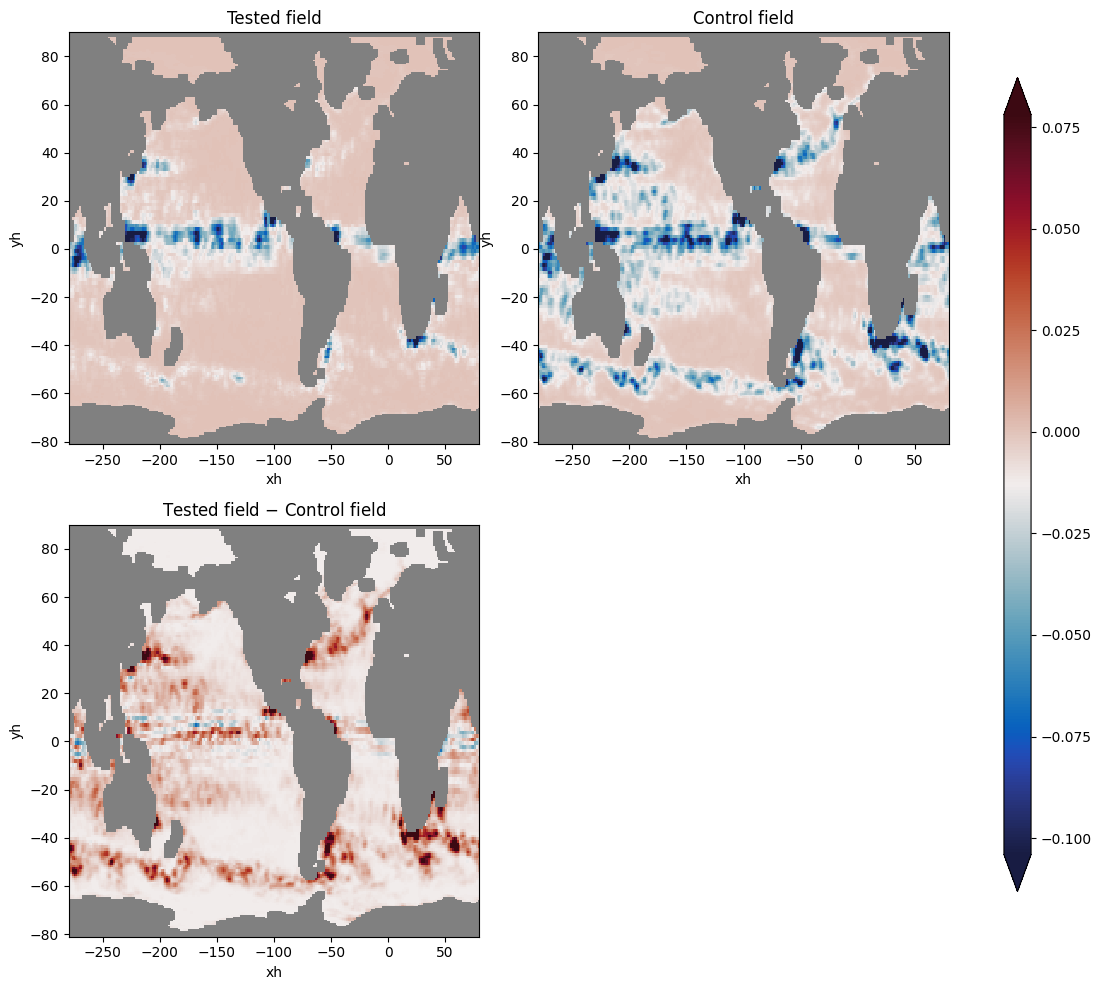

In [90]:
compare((mask2_nan.values * ann_exp1[15].Txx_pred)[0], (mask2_nan.values * ann_exp1[15].Txx)[0], selector=select_globe)

Correlation: 0.7039048287302587
Relative Error: 0.7413527693882497
R2 =  0.42134240165270676
R2 max =  0.5569725752450932
Optinal scaling: 1.9742189337882368
Nans [test/control]: [22194, 22194]


array([[<Axes: title={'center': 'Tested field'}, xlabel='xh', ylabel='yh'>,
        <Axes: title={'center': 'Control field'}, xlabel='xh', ylabel='yh'>],
       [<Axes: title={'center': 'Tested field $-$ Control field'}, xlabel='xh', ylabel='yh'>,
        <Axes: >]], dtype=object)

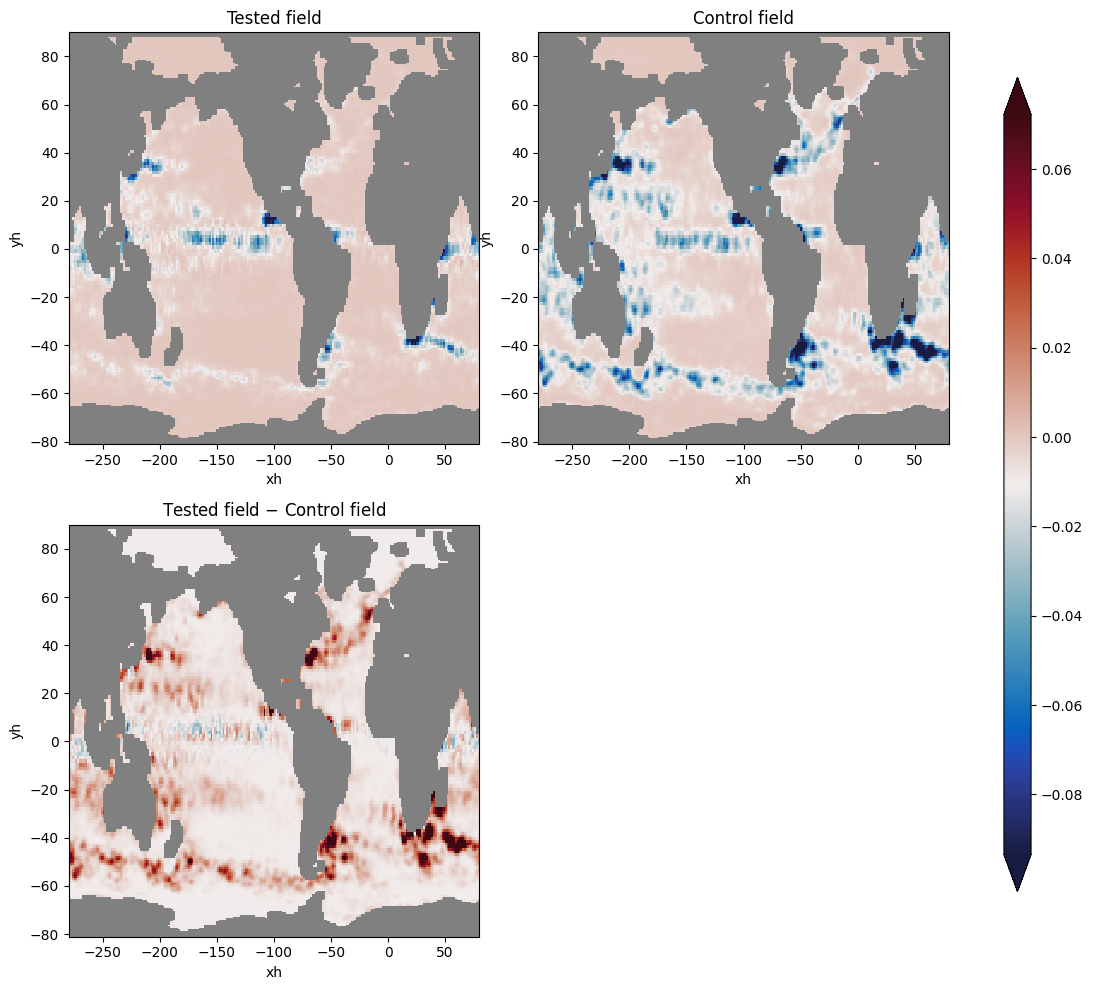

In [91]:
compare((mask2_nan.values * ann_exp1[15].Tyy_pred)[0], (mask2_nan.values * ann_exp1[15].Tyy)[0], selector=select_globe)

Correlation: 0.5916436879607776
Relative Error: 0.8340912952194298
R2 =  0.34897424693489265
R2 max =  0.34975198616628156
Optinal scaling: 1.0494897320541852
Nans [test/control]: [22194, 22194]


array([[<Axes: title={'center': 'Tested field'}, xlabel='xh', ylabel='yh'>,
        <Axes: title={'center': 'Control field'}, xlabel='xh', ylabel='yh'>],
       [<Axes: title={'center': 'Tested field $-$ Control field'}, xlabel='xh', ylabel='yh'>,
        <Axes: >]], dtype=object)

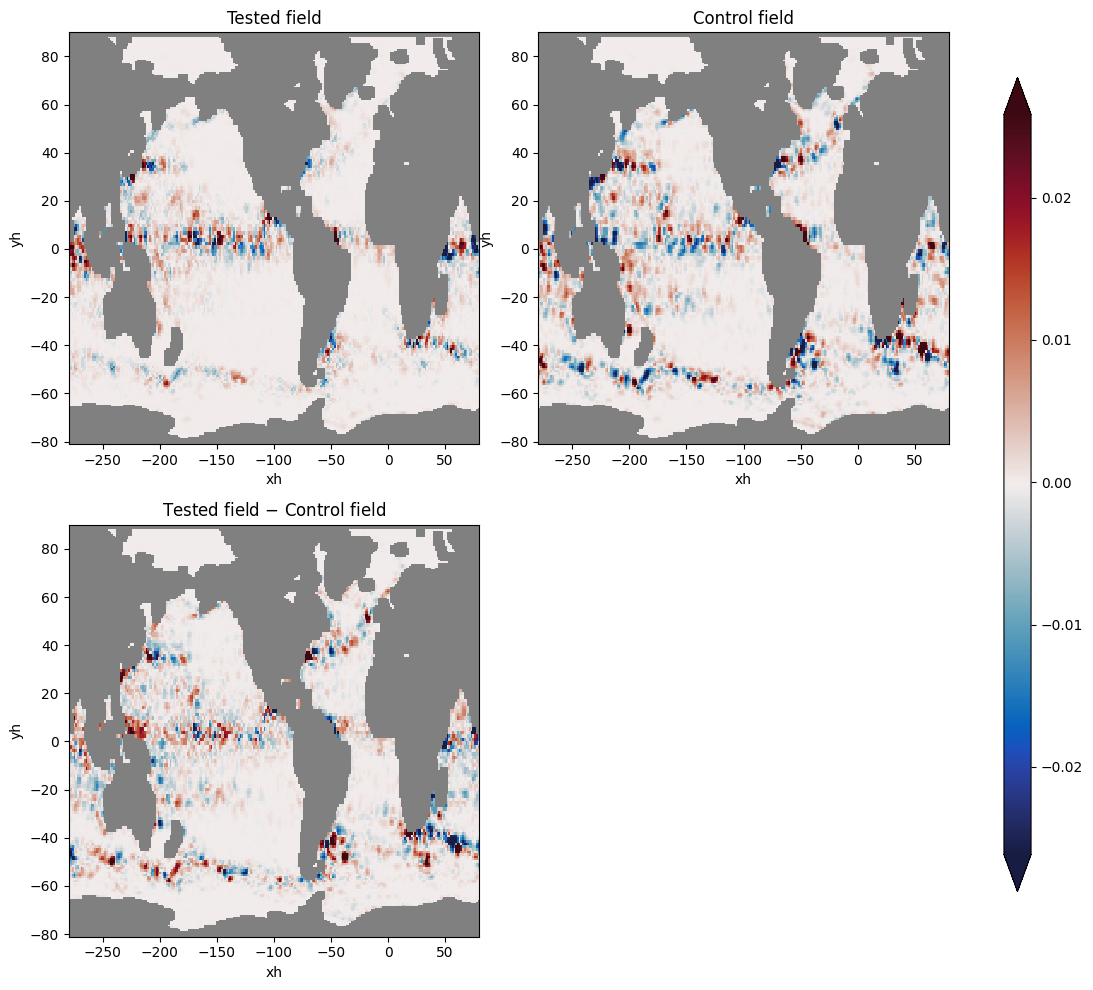

In [92]:
compare((mask2_nan.values * ann_exp1[15].Txy_pred)[0], (mask2_nan.values * ann_exp1[15].Txy)[0], selector=select_globe)

In [95]:
(0.5620693914071246 + 0.42134240165270676 + 0.34897424693489265) / 3

0.44412867999824135